# Reportar Producción Científica
## English

Reportar producción científica para generar CV en inglés

In [8]:
import csv
import pandas as pd
import datetime
#!pip install pyparsing
import pyparsing
#!pip install bibtexparser
import bibtexparser
import sys
sys.path.append('..')

import os
from os import path
from datetime import timedelta

#!pip install numpy
import numpy as np
import matplotlib.pyplot as plt
import report_utils as ru

In [9]:
# Fechas del reporte
date_inicio = datetime.datetime(2008,8,1)
date_fin = datetime.datetime(2026,12,31)

# direccion de la base de datos
database_folder = '../../database/'


## Read databases

In [10]:
## Papers
with open(database_folder + 'myproducts.bib') as bibtex_file:
    bibtex_str = bibtex_file.read()

bib_database = bibtexparser.loads(bibtex_str)
productos = ru.categorize_bibliography_entries(bib_database, date_inicio, date_fin)

# Teaching
teaching = []
with open(database_folder + 'teaching.csv', 'r') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        dictio = dict(row)
        teaching.append(dictio)

 
# Talks
talks = []
with open(database_folder + 'talks.csv', 'r') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        dictio = dict(row)
        talks.append(dictio)
        
# Developments
developments = []
with open(database_folder + 'developments.csv', 'r') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        dictio = dict(row)
        developments.append(dictio)
        



In [11]:
print(f"{productos['total']} products found")
print(f"{productos['jcr']['count']} JCR products found")
print(f"{productos['proc']['count']} Proceedings found")
print(f"{productos['mt']['count']} Master Thesis found")
print(f"{productos['phd']['count']} PhD Thesis found")
print(f"{productos['cona']['count']} conacyt articles")
print(f"{productos['preprint']['count']} preprints")
print(f"{productos['divul']['count']} divulgacion")
print(f"{productos['otros']['count']} otros")

58 products found
24 JCR products found
15 Proceedings found
9 Master Thesis found
4 PhD Thesis found
0 conacyt articles
2 preprints
4 divulgacion
0 otros


In [12]:
# Verificar que existe el folder 'text', si no existe crearlo
if not path.exists('text'):
    os.mkdir('text')

## Publications

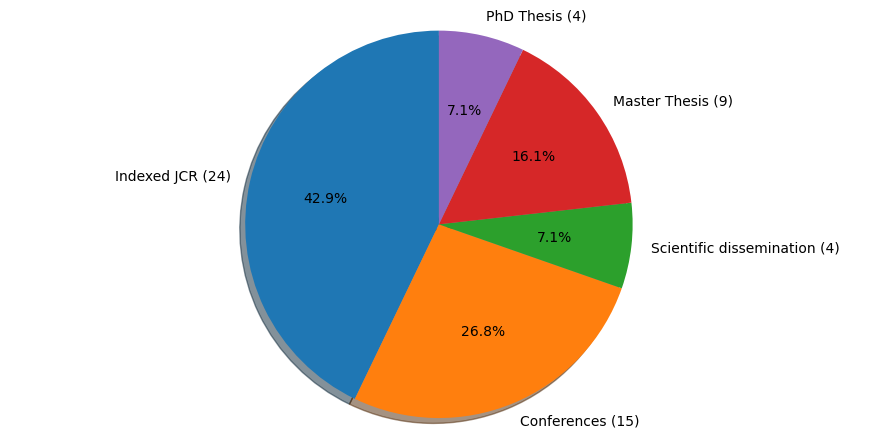

In [13]:
labels = []
publicaciones = []

# Graficar los productos
if  productos['jcr']['count'] > 0:
    publicaciones.append(productos['jcr']['count'])
    labels.append(f"Indexed JCR ({str(productos['jcr']['count'])})")
    
if productos['proc']['count'] > 0:
    publicaciones.append(productos['proc']['count'])
    labels.append(f"Conferences ({str(productos['proc']['count'])})")
if productos['divul']['count'] > 0:
    publicaciones.append(productos['divul']['count'])
    labels.append(f"Scientific dissemination ({str(productos['divul']['count'])})")

if productos['mt']['count'] > 0:
    publicaciones.append(productos['mt']['count'])
    labels.append(f"Master Thesis ({str(productos['mt']['count'])})")
if productos['phd']['count'] > 0:
    publicaciones.append(productos['phd']['count'])
    labels.append(f"PhD Thesis ({str(productos['phd']['count'])})")

if productos['cona']['count'] > 0:
    publicaciones.append(productos['cona']['count'])
    labels.append(f"Conacyt Articles ({str(productos['cona']['count'])})")
    
fig, ax1 = plt.subplots(figsize=(9, 4.5), subplot_kw=dict(aspect="equal"))

ax1.pie(publicaciones, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90)
# Equal aspect ratio ensures that pie is drawn as a circle
ax1.axis('equal')  
plt.tight_layout()
plt.savefig("text/products_en.pdf", format='pdf')
plt.savefig("text/products_en.png", format='png')
plt.show()


In [14]:
# Crear un archivo .tex para la producción científica
# Articulos JCR

# write data in a file. 
file1 = open("text/jcr_journals.tex","w") 
#L = ["This is Delhi \n","This is Paris \n","This is London \n"]  
  
# \n is placed to indicate EOL (End of Line) 
if count_jcr > 0:
    file1.write("\\begin{itemize} \n") 
    
    jcr_entries = sorted(jcr_entries, key = lambda i: i['year'], reverse = True)
    
    for entry in jcr_entries:
        file1.write(f"\\item {entry['author']}, {entry['title']},\\textit{{ {entry['journal']},}} ({entry['year']}),") 
        if 'doi' in entry.keys():
            file1.write(f" \\href{{{entry['doi']}}} {{\\faFilePdfO}},")
        file1.write(f" I.F. {entry['if']} \n")
    file1.write("\\end{itemize} \n")                     
                                        
file1.close() #to change file access modes 


NameError: name 'count_jcr' is not defined

In [ ]:
# CONACYT

# write data in a file. 
file1 = open("text/conacyt_journals.tex","w") 
#L = ["This is Delhi \n","This is Paris \n","This is London \n"]    
                    
if count_cona > 0:
    file1.write("\\begin{itemize} \n") 
    
    cona_entries = sorted(cona_entries, key = lambda i: i['year'], reverse = True)
    
    for entry in cona_entries:
        file1.write(f"\\item {entry['author']}, {entry['title']},\\textit{{ {entry['journal']},}} ({entry['year']}) \n") 
                    
    file1.write("\\end{itemize} \n")                  
                                        
file1.close() #to change file access modes 

In [ ]:
# CONFERENCIAS

# write data in a file. 
file1 = open("text/proceedings.tex","w") 
                                      
if count_proc > 0:
   file1.write("\\begin{itemize} \n") 
                    
   proc_entries = sorted(proc_entries, key = lambda i: i['year'], reverse = True)
                    
   for entry in proc_entries:
        file1.write(f"\\item {entry['author']}, {entry['title']}, \\textit{{ {entry['booktitle']},}} {entry['year']} \n")        

   file1.write("\\end{itemize} \n")                     
                                        
file1.close() #to change file access modes 

## Estudiantes

Crear un archivo tex para la formación de recursos humanos

In [ ]:
# MAESTRIA

# write data in a file. 
file1 = open("text/master_students.tex","w")

#file1.write("\\item{\\bf GRADUATED MASTER STUDENTS: }\n")
    
if count_mt > 0:
    #file1.write("Tesis de maestría dirigidas: \n")
    file1.write("\\begin{itemize} \n")
    
    mt_entries = sorted(mt_entries, key = lambda i: i['year'], reverse = True)
                    
    for entry in mt_entries:
        file1.write(f"\\item {entry['author']}, \\textit{{ {entry['title']} }}, \\href{{ {entry['link']} }}{{\\faFilePdfO}}, {entry['year']}, {entry['school']}. \n")        

    file1.write("\\end{itemize} \n") 
                    
file1.close() #to change file access modes 

## Clases

In [ ]:
# Teaching
def toDate(cadena):
    return datetime.datetime.strptime(cadena, '%Y/%m/%d')

# list products between dates
count_sub = 0
total_hours = 0

for subject in teaching:
    #print(toDate(subject['Inicio']).year)
    if date_inicio <= toDate(subject['Inicio']) and date_fin >= toDate(subject['Fin']):
        count_sub += 1
        total_hours += int(subject['Horas'])     
        
print(f"{count_sub} materias impartidas")
print(f"{total_hours} horas impartidas")


# write data in a file. 
file1 = open("text/teaching.tex","w")

#file1.write("\\item{\\bf GRADUATED MASTER STUDENTS: }\n")
    
if len(teaching) > 0:
    #teaching = sorted(teaching, key = lambda i: i['year'], reverse = True)
    
    file1.write("\\begin{itemize} \n")
                    
    for entry in teaching:
        file1.write(f"\\item {entry['Inicio']}, \\textit{{ {entry['Nombre']},}} nivel {entry['Nivel']}, {entry['Horas']} horas. \n")        

    file1.write("\\end{itemize} \n") 
                    
file1.close() #to change file access modes 

28 materias impartidas
1548 horas impartidas


## Desarrollos tecnológicos

In [ ]:
# Desarrollos tecnológicos

file1 = open("text/developments.tex","w")

if len(developments) > 0:
    #teaching = sorted(teaching, key = lambda i: i['year'], reverse = True)
    file1.write("\\begin{itemize} \n")
                    
    for entry in developments:
        file1.write(f"\\item {entry['Date']}, \\textit{{ {entry['Name']},}} {entry['User']}, {entry['License']}, {entry['Validation']} \n")        

    file1.write("\\end{itemize} \n") 
                    
file1.close() #to change file access modes 

## Vinculación y divulgación

In [ ]:
# Talks

# write data in a file. 
file1 = open("text/talks.tex","w")

if len(talks) > 0:
    file1.write("\\begin{itemize} \n") 
    
    talks = sorted(talks, key = lambda i: i['year'], reverse = True)
        
    for entry in talks:
        if entry['Type'] == 'platica':
            file1.write(f"\\item {entry['Date']}, {entry['Title']}, en \\textit{{ {entry['Event']},}} {entry['Place']} \n")            

    file1.write("\\end{itemize} \n") 
                        
file1.close() #to change file access modes 

In [ ]:
# Workshops

# write data in a file. 
file1 = open("text/workshop.tex","w")

if len(talks) > 0:
    file1.write("\\begin{itemize} \n") 
    
    talks = sorted(talks, key = lambda i: i['year'], reverse = True)
        
    for entry in talks:
        if entry['Type'] == 'taller':
            file1.write(f"\\item {entry['Date']}, {entry['Title']}, en \\textit{{ {entry['Event']},}} {entry['Place']} \n")            

    file1.write("\\end{itemize} \n") 
                        
file1.close() #to change file access modes 

In [ ]:
# Divulgación
# write data in a file. 
file1 = open("text/divulgacion.tex","w") 
#L = ["This is Delhi \n","This is Paris \n","This is London \n"]  
  
# \n is placed to indicate EOL (End of Line) 
if count_jcr > 0:
    file1.write("\\begin{itemize} \n") 
    
    jcr_entries = sorted(divul_entries, key = lambda i: i['year'], reverse = True)
    
    for entry in jcr_entries:
        file1.write(f"\\item {entry['author']}, {entry['title']},\\textit{{ {entry['journal']},}} ({entry['year']})\n") 
                    
    file1.write("\\end{itemize} \n")                     
                                        
file1.close() #to change file access modes 

### Preprints

In [ ]:
# Crear un archivo .tex para los preprints
  
if count_preprint > 0:
    # write data in a file. 
    file1 = open("text/preprints.tex","w") 

    #file1.write("\n Preprints:")
    file1.write("\\begin{itemize} \n") 
    
    for entry in preprint_entries:
        file1.write(f"\\item {entry['author']}, {entry['title']}, {entry['journal']}, {entry['year']}, \\href{{{entry['link']}}}{{\\faFilePdfO}} \n") 
                    
    file1.write("\\end{itemize} \n") 
                    
    file1.close() #to change file access modes 

else:
    # write data in a file. 
    file1 = open("text/preprints.tex","w") 

    file1.close() #to change file access modes 

### Call latex


In [ ]:
# execute latex
os.system('cd templates; pdflatex -synctex=1 -interaction=nonstopmode cv_jivg_en_full.tex')

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=pdflatex)
 restricted \write18 enabled.
entering extended mode
(./cv_jivg_en_full.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/fancyhdr/fancyhdr.sty)
(/usr/share/texlive/texmf-dist/tex/latex/amsmath/amsmath.sty
For additional information on amsmath, use the `?' option.
(/usr/share/texlive/texmf-dist/tex/latex/amsmath/amstext.sty
(/usr/share/texlive/texmf-dist/tex/latex/amsmath/amsgen.sty))
(/usr/share/texlive/texmf-dist/tex/latex/amsmath/amsbsy.sty)
(/usr/share/texlive/texmf-dist/tex/latex/amsmath/amsopn.sty))
(/usr/share/texlive/texmf-dist/tex/latex/amsfonts/amssymb.sty
(/usr/share/texlive/texmf-dist/tex/latex/amsfonts/amsfonts.sty))
(/usr/s

256

In [ ]:
# open
os.system('xdg-open templates/cv_jivg_en_full.pdf > /dev/null')

0